In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
from pandas import DataFrame,Series

In [2]:
df=pd.read_csv("/content/Advertising.csv")

In [3]:
df

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [4]:
df.drop(columns=["Unnamed: 0"],inplace=True)

In [5]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [6]:
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [7]:
X=df.drop(columns=["Sales"])
X.head(2)

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1


In [8]:
Y=df["Sales"]
Y.head(2)

,Sales
0,22.1
1,10.4


# Training and testing the dataset

1. Load the Data: You upload your dataset into Colab and load it using Python libraries like Pandas.

2. Split the Data: You use the train_test_split function from the Scikit-Learn library to randomly divide your data into training and testing sets.

3. Train: You call the .fit() method on your machine learning algorithm using the training data.

4. Test: You call the .predict() method using the testing data, and then measure how accurate your model is.

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=0)

In [10]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(160, 3) (40, 3) (160,) (40,)


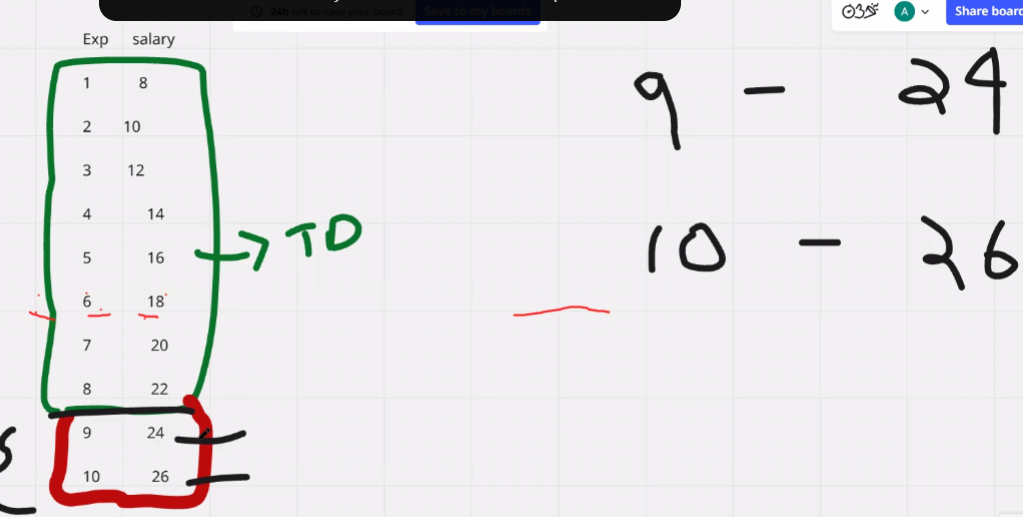

Green color is for training data

Red color is for testing data

X_train,Y_ train used to study the pattern of data
X_test and Y_test used to see how well the data got trained

In our example we got output as "(160, 3) (40, 3) (160,) (40,)" means 140 samples are for training and 40 are for testing 3 are features(X) for each sample

# Train the model

In [11]:
from sklearn.linear_model import LinearRegression
linear_reg=LinearRegression()

In [12]:
linear_reg.fit(x_train, y_train)

LinearRegression()

y=mx+c

we have 3 dependent values so we will get 3 "m" values

In [13]:
linear_reg.intercept_  #c value

np.float64(2.99489303049533)

In [14]:
linear_reg.coef_  #m1,m2,m3 values

array([ 0.04458402,  0.19649703, -0.00278146])

In [15]:
df.head(3)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3


y=mx+c

Sales=m1 * TV, m2 * Radio, m3 * Newspaper + c

Sales = (( 0.04458402 * 230.1)+(0.19649703 * 37.8)+(-0.00278146 * 69.2) ) + 2.994

In [16]:
Sales = (( 0.04458402 * 230.1)+(0.19649703 * 37.8)+(-0.00278146 * 69.2) ) + 2.994
Sales

20.487893704

In [17]:
y_predict=linear_reg.predict(x_test)
y_predict

array([10.05739563,  7.4522807 ,  7.0197076 , 24.08029725, 12.01786259,
        6.53793858, 12.78286918, 15.10974587, 10.76974013, 16.34357951,
       22.88297477,  9.12924467, 10.46455672, 15.48743552, 11.58555633,
       12.17296914, 18.76551502, 10.78318566, 15.90515992, 17.30651279,
       24.06692057,  9.59834224, 15.13512211, 12.38591525,  5.71360885,
       15.24749314, 12.29402334, 20.9421167 , 13.40991558,  9.04348832,
       12.89239415, 21.40272028, 18.13802209, 21.17320803,  6.56974433,
        6.14114206,  7.89018394, 13.01541434, 14.68953791,  6.18835143])

In [18]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(y_test,y_predict)
mse

4.402118291449685

In [19]:
np.sqrt(mse)

np.float64(2.0981225634956804)

2.0981 is the error value for y_test

In [20]:
df.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [21]:
linear_reg.predict([[17.2,45.9,69.3]])[0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


np.float64(12.588196590344332)

# Let's install gradio

In [22]:
%%capture
pip install gradio

In [23]:
import gradio as gr

def greet(name):
  return "Hello "+name+"!"

In [24]:
greet("Harsha")

'Hello Harsha!'

In [25]:
demo = gr.Interface(fn=greet, inputs="text", outputs="text")
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://402abebf4af3d2e8a0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [26]:
def predict_sales(tv, radio, newspaper):
    prediction = linear_reg.predict([[tv, radio, newspaper]])
    return prediction[0]

demo = gr.Interface(fn=predict_sales,inputs=[gr.Number(label="TV"),gr.Number(label="Radio"),gr.Number(label="Newspaper")],
    outputs="number")

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4c9be116452507b6ce.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


**Above code can be written in this way**

def predict_sales(tv, radio, newspaper):
    prediction = linear_reg.predict([[tv, radio, newspaper]])
    return prediction[0]

demo = gr.Interface(fn=predict_sales,inputs=["number","number","number"],outputs="number")

demo.launch(share=True)

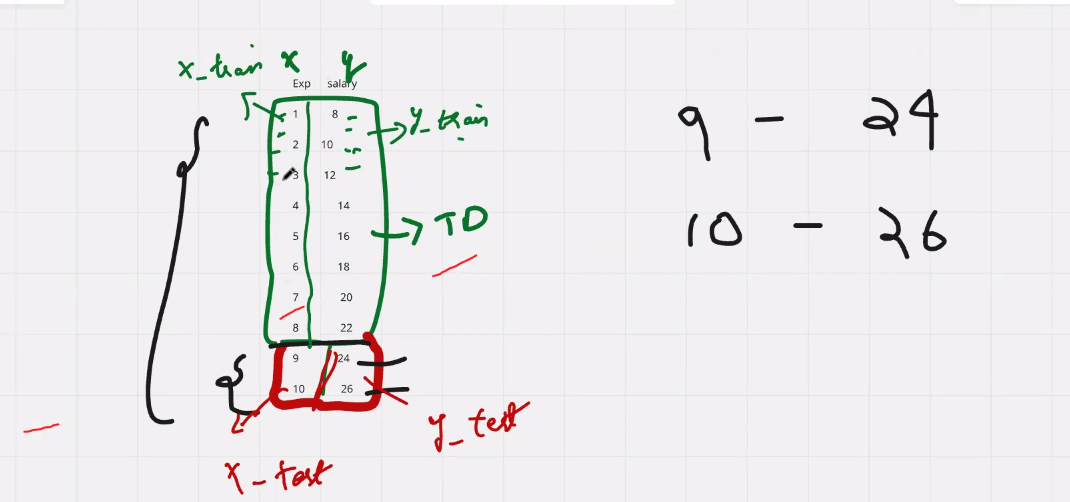